<a href="https://colab.research.google.com/github/ElroySTBN/-hh/blob/main/Copie_de_Danone_Horizon_simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Group Project — Corporate Finance
## Danone — Divestiture of Horizon Organic & Wallaby to Platinum Equity

**Company:** Danone SA (BN FP) | **Peers:** Nestlé (NESN SW), Unilever (ULVR LN)  
**Event:** Announcement 26-Jan-2023 | Signing 01-Jan-2024  
**Data:** WRDS Compustat (financials + daily prices), Bloomberg (events + market inputs)

**Notebook structure (follows the project brief):**  
A — Project overview · B — Financial ratios · C — Working capital & capital structure  
D — WACC · D-bis — Event study on stock price · E — Real options & alternatives

## Setup

In [ ]:
# Same libraries as in class (Sessions 1, 2, 4, 7)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True

**Upload the 2 raw data files** (financials + daily stock prices):

In [ ]:
from google.colab import files
uploaded = files.upload()  # select both files at once

Saving Danone_Project_RawData_for_python.xlsx to Danone_Project_RawData_for_python (1).xlsx
Saving Danone_Project_StockPrices.xlsx to Danone_Project_StockPrices.xlsx


In [ ]:
# Load financials (1 row = 1 company × 1 year) and stock prices
fin = pd.read_excel('Danone_Project_RawData_for_python.xlsx', sheet_name='financials')
fin = fin[fin['fyear'] <= 2024].copy()  # keep 5 complete years (2020-2024)

prices = pd.read_excel('STOCK_price_python.xlsx', sheet_name='prices_wide',
                       parse_dates=['date'], index_col='date')

print('Financials:', fin.shape, '| Prices:', prices.shape)
fin.head()

Financials: (15, 25) | Prices: (1638, 3)


,company,ticker,currency,fyear,datadate,revenue,ebit,ebitda,net_income,pretax_income,...,receivables,inventory,current_liabilities,payables,short_term_debt,long_term_debt,equity,cfo,capex,depreciation
0,Danone,BN FP,EUR,2020,2020-12-31,23620,3329,4418,1956,2792,...,3362,1840,10338,3467,3762,12272,16205,2967,962,1089
1,Danone,BN FP,EUR,2021,2021-12-31,24281,3335,4543,1924,2580,...,3616,1982,11078,3998,3767,12442,17273,3474,1043,1208
2,Danone,BN FP,EUR,2022,2022-12-31,27661,3383,4470,959,1801,...,4142,2619,12130,4899,3357,10806,17923,2964,873,1087
3,Danone,BN FP,EUR,2023,2023-12-31,27619,3491,4944,881,1721,...,3809,2341,13828,4779,5154,10447,16176,3442,847,1453
4,Danone,BN FP,EUR,2024,2024-12-31,27376,3196,4242,2021,3029,...,3900,2277,13732,5147,4291,9929,17795,3831,923,1046


# A. Project Overview

**Danone** = French FMCG group (Dairy & Plant-Based, Waters, Specialized Nutrition).  
In **Jan 2023**, it announced the sale of US organic dairy brands **Horizon Organic** and **Wallaby** to **Platinum Equity** (signed Jan 2024). Danone keeps a **minority stake**.

**Why?** These brands = ~3% of revenues but **dilutive on margins**. Part of the **Renew Danone strategy** (CEO de Saint-Affrique, March 2022) → portfolio rotation of ~10% of sales toward higher-margin businesses.

**Communication:** Press release (26-Jan-2023, also on Bloomberg). Sell-side positive (RBC buy, Barclays overweight). Final signing: PR Newswire (01-Jan-2024).

**Peers chosen:** Nestlé and Unilever — closest comparables (FMCG, Europe-listed, similar consumer staples profile).

# B. Financial Performance & Ratio Analysis
10 standard ratios from class (Session 2).

In [ ]:
# Profitability
fin['operating_margin']  = fin['ebit'] / fin['revenue']
fin['net_margin']        = fin['net_income'] / fin['revenue']
fin['roe']               = fin['net_income'] / fin['equity']
fin['roce']              = fin['ebit'] / (fin['equity'] + fin['short_term_debt'] + fin['long_term_debt'] - fin['cash'])

# Liquidity
fin['current_ratio']     = fin['current_assets'] / fin['current_liabilities']

# Leverage
fin['total_debt']        = fin['short_term_debt'] + fin['long_term_debt']
fin['net_debt']          = fin['total_debt'] - fin['cash']
fin['net_debt_ebitda']   = fin['net_debt'] / fin['ebitda']
fin['interest_coverage'] = fin['ebit'] / fin['interest_expense']

# Cash generation
fin['cfo_revenue']       = fin['cfo'] / fin['revenue']
fin['fcf']               = fin['cfo'] - fin['capex']
fin['fcf_revenue']       = fin['fcf'] / fin['revenue']

# Growth (year-over-year, within each company)
fin = fin.sort_values(['company', 'fyear'])
fin['revenue_growth'] = fin.groupby('company')['revenue'].pct_change()

# Show Danone's ratios
ratio_cols = ['revenue_growth','operating_margin','net_margin','roe','roce',
              'current_ratio','net_debt_ebitda','interest_coverage','cfo_revenue','fcf_revenue']
fin[fin['company']=='Danone'][['fyear'] + ratio_cols].set_index('fyear').T.round(3)

fyear,2020,2021,2022,2023,2024
revenue_growth,NaN,0.03,0.14,-0.00,-0.01
operating_margin,0.14,0.14,0.12,0.13,0.12
net_margin,0.08,0.08,0.04,0.03,0.07
roe,0.12,0.11,0.05,0.05,0.11
roce,0.12,0.12,0.12,0.14,0.12
current_ratio,1.03,1.09,1.00,0.93,0.93
net_debt_ebitda,2.66,2.28,2.12,1.94,1.90
interest_coverage,9.30,10.32,10.98,6.80,5.33
cfo_revenue,0.13,0.14,0.11,0.12,0.14
fcf_revenue,0.09,0.10,0.08,0.09,0.11


**Source:** WRDS Compustat (`sale`, `ebit`, `ib`, `ceq`, `dlc`+`dltt`, etc.).  
**If asked "how did you get these?":** *We applied the standard ratio formulas from class on the WRDS variables.*

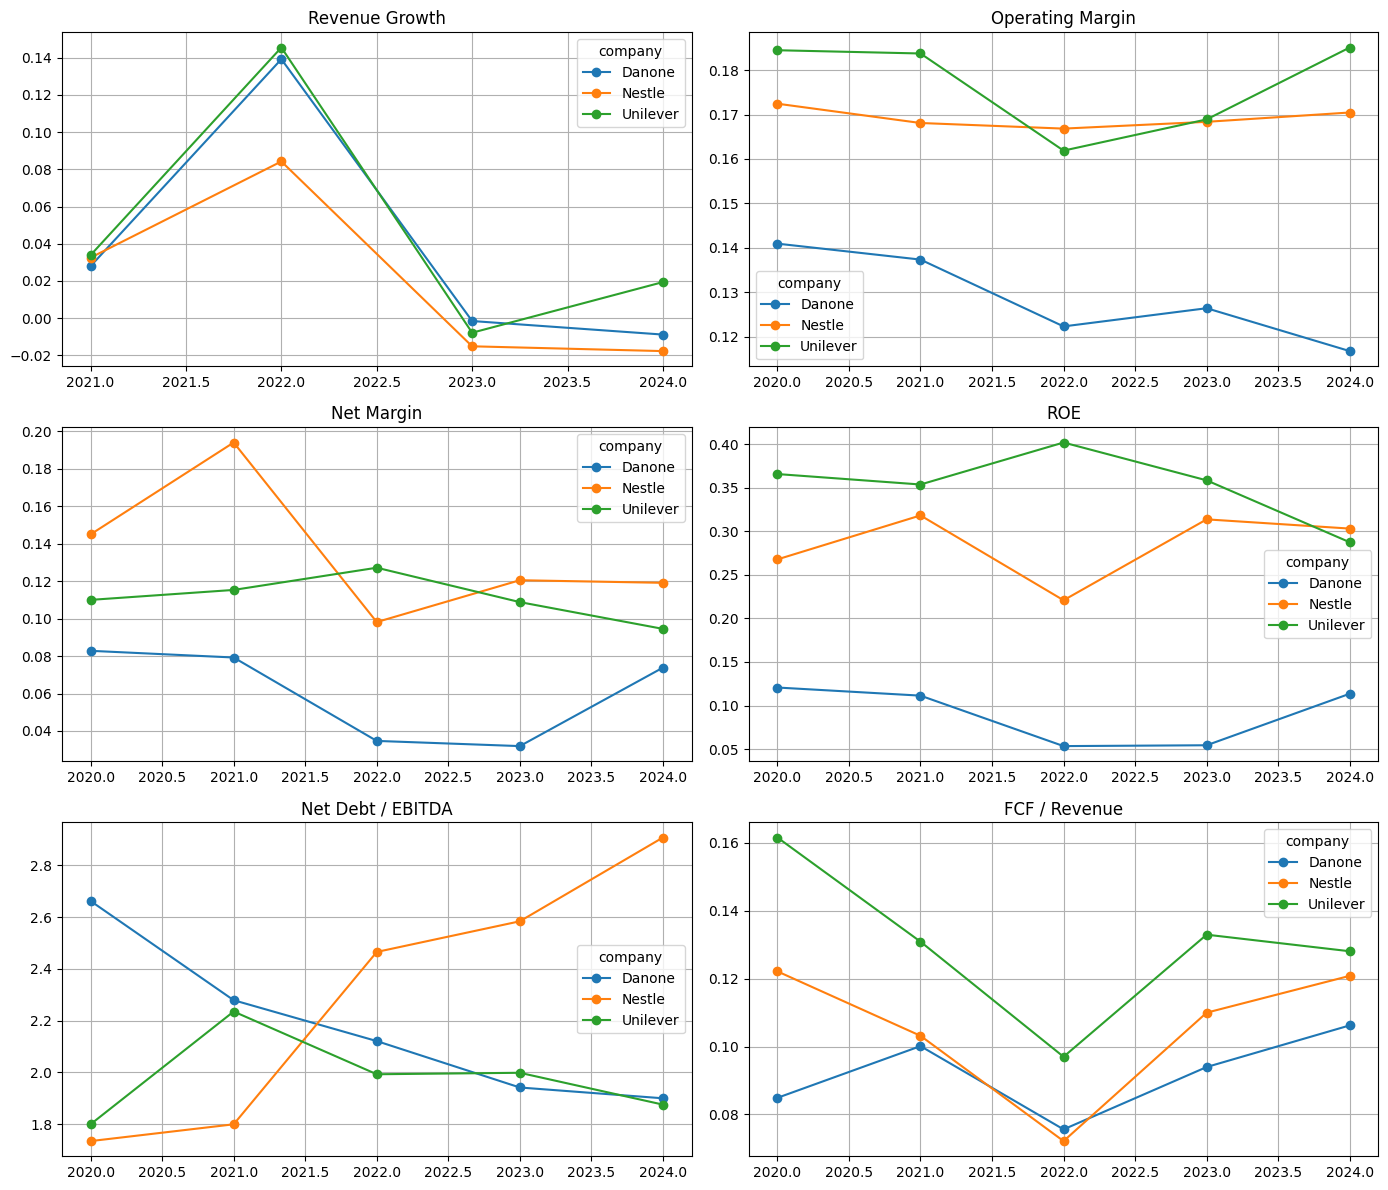

In [ ]:
# Helper: pivot a ratio across companies (rows=years, cols=companies)
def pivot_ratio(name):
    return fin.pivot(index='fyear', columns='company', values=name)

# Plot the 6 most important ratios
ratios_to_plot = [
    ('revenue_growth',   'Revenue Growth'),
    ('operating_margin', 'Operating Margin'),
    ('net_margin',       'Net Margin'),
    ('roe',              'ROE'),
    ('net_debt_ebitda',  'Net Debt / EBITDA'),
    ('fcf_revenue',      'FCF / Revenue'),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for ax, (r, t) in zip(axes.flat, ratios_to_plot):
    pivot_ratio(r).plot(ax=ax, marker='o')
    ax.set_title(t); ax.set_xlabel('')
plt.tight_layout(); plt.show()

**Key observations:**
- Danone's operating margin (~12%) is **structurally below peers** (~17–18%) → justifies the portfolio cleanup.
- Danone is the **only one deleveraging** (Net Debt/EBITDA: 2.7x → 1.9x), Nestlé does the opposite.
- Danone's FCF/Revenue **catching up** with peers (8% → 11%) → first sign that Renew works.

### Pre vs post (FY2022 vs FY2024) — direct answer to *"observable financial impact?"*

In [ ]:
# Compare 2022 (last full year with Horizon) vs 2024 (post-disposal)
metrics = ['operating_margin','net_margin','roe','net_debt_ebitda','fcf_revenue']

def delta(co, m):
    """Change in metric m for company co, between 2022 and 2024."""
    v22 = fin[(fin['company']==co) & (fin['fyear']==2022)][m].iloc[0]
    v24 = fin[(fin['company']==co) & (fin['fyear']==2024)][m].iloc[0]
    return v24 - v22

event_table = pd.DataFrame({co: [delta(co, m) for m in metrics] for co in ['Danone','Nestle','Unilever']},
                            index=metrics)
event_table.columns = ['Δ Danone','Δ Nestlé','Δ Unilever']

# Net effect = Danone change minus average peer change → isolates the Danone-specific part
event_table['Peer Avg Δ'] = (event_table['Δ Nestlé'] + event_table['Δ Unilever']) / 2
event_table['Net Effect'] = event_table['Δ Danone'] - event_table['Peer Avg Δ']
event_table.round(4)

,Δ Danone,Δ Nestlé,Δ Unilever,Peer Avg Δ,Net Effect
operating_margin,-0.01,0.00,0.02,0.01,-0.02
net_margin,0.04,0.02,-0.03,-0.01,0.04
roe,0.06,0.08,-0.11,-0.02,0.08
net_debt_ebitda,-0.22,0.44,-0.12,0.16,-0.38
fcf_revenue,0.03,0.05,0.03,0.04,-0.01


**Reading the table — net effect = the Danone-specific change after removing sector trends:**
- Net margin: **+4 pts** specific to Danone
- ROE: **+8 pts** specific to Danone
- Net Debt/EBITDA: **−0.4x** (Danone deleverages while peers re-leverage)

**Why peers as control:** if Danone moves opposite to peers, the change is Danone-specific, not a sector trend. Simplified difference-in-differences logic.  
**Limit:** disposal closed during 2024 → only partial-year impact visible. Full effect expected in 2025.

# C. Working Capital & Capital Structure
## C.1 Working Capital — Cash Conversion Cycle (Session 5)

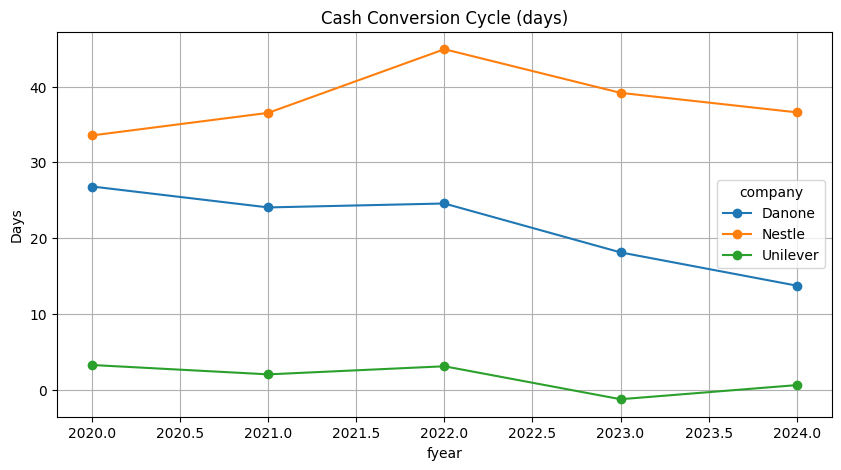

company,Danone,Nestle,Unilever
fyear,,,
2020,26.80,33.60,3.30
2021,24.10,36.50,2.00
2022,24.60,44.90,3.10
2023,18.10,39.20,-1.30
2024,13.70,36.60,0.60


In [ ]:
# DSO, DIO, DPO — formulas from class
fin['dso'] = (fin['receivables'] / fin['revenue']) * 365
fin['dio'] = (fin['inventory']    / fin['revenue']) * 365   # proxy: Revenue (no COGS in WRDS extract)
fin['dpo'] = (fin['payables']     / fin['revenue']) * 365
fin['ccc'] = fin['dso'] + fin['dio'] - fin['dpo']

# Plot CCC
ccc_wide = fin.pivot(index='fyear', columns='company', values='ccc')
ax = ccc_wide.plot(marker='o', title='Cash Conversion Cycle (days)')
ax.set_ylabel('Days'); plt.show()
ccc_wide.round(1)

**Formula:** CCC = DSO + DIO − DPO (Session 5).  
**Result:** Danone's CCC drops from **27 days (2020) to 14 days (2024)** → much less working capital needed per euro of sales.  
**Limit:** we use Revenue instead of COGS in DIO/DPO (no COGS column in WRDS extract). Overstates the level uniformly across all 3 companies → trend and comparison stay valid.

## C.2 Capital Structure

In [ ]:
fin['debt_to_equity'] = fin['total_debt'] / fin['equity']
fin['debt_to_assets'] = fin['total_debt'] / fin['total_assets']

# Danone's capital structure over time
fin[fin['company']=='Danone'][['fyear','total_debt','net_debt','debt_to_equity','debt_to_assets']]\
   .set_index('fyear').round(3)

,total_debt,net_debt,debt_to_equity,debt_to_assets
fyear,,,,
2020,16034,11761,0.99,0.38
2021,16209,10353,0.94,0.36
2022,14163,9481,0.79,0.31
2023,15601,9600,0.96,0.35
2024,14220,8060,0.80,0.31


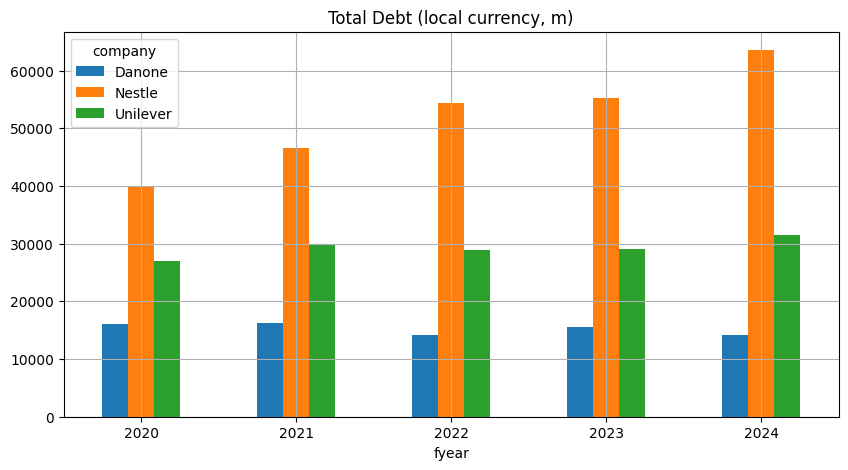

In [ ]:
# Plot total debt for the 3 companies
fin.pivot(index='fyear', columns='company', values='total_debt')\
   .plot(kind='bar', title='Total Debt (local currency, m)')
plt.xticks(rotation=0); plt.show()

**How was the project financed?**  
Disposal = NOT a financing event → it **generates cash**.  
- Danone Total Debt: €15,601m (2023) → €14,220m (2024) = **~€1.4bn debt reduction**.  
- Matches the timing of disposal proceeds → the cash was used to **pay down debt**.

**vs peers:** D/E ~0.8x (in line with Unilever, lower than Nestlé). Danone is the only one **actively deleveraging**.

# D. Cost of Capital — WACC
Same procedure as **Session 4** (ABC Corporation case).

## D.1 Bloomberg market inputs
| Input | Source | Why |
|---|---|---|
| **Market Cap (E)** | Bloomberg `CUR_MKT_CAP` | Need market value of equity for WACC weights |
| **Risk-free rate (Rf)** | 10Y sovereign bond in reporting currency | Long-term horizon = corporate investments |
| **Equity Risk Premium (ERP)** | Damodaran (~5.5%) | Standard developed-markets estimate |
| **Beta (β)** | Bloomberg `BETA` (5Y weekly) | Sensitivity to local market |

**Why these specific Rf values?**  
Danone & Unilever report in EUR → French OAT 10Y (~3.0%). Nestlé reports in CHF → Swiss 10Y (~1.0%).  
**Why same ERP for all 3?** They all operate in mature European markets.  
**Why beta < 1 for all 3?** Defensive consumer staples (less volatile than the market).

In [ ]:
# Bloomberg market inputs (placeholders to refresh with terminal values)
wacc_inputs = pd.DataFrame({
    'company': ['Danone',  'Nestle',  'Unilever'],
    'mcap':    [45000,     215000,    130000],   # market cap (local currency m)
    'rf':      [0.030,     0.010,     0.030],    # 10Y sovereign yield
    'erp':     [0.055,     0.055,     0.055],    # Damodaran ERP
    'beta':    [0.75,      0.55,      0.65],     # Bloomberg 5Y weekly beta
}).set_index('company')
wacc_inputs

,mcap,rf,erp,beta
company,,,,
Danone,45000,0.03,0.06,0.75
Nestle,215000,0.01,0.06,0.55
Unilever,130000,0.03,0.06,0.65


## D.2 WACC formula (Session 4)
$WACC = \\frac{E}{E+D} \\cdot R_e + \\frac{D}{E+D} \\cdot R_d \\cdot (1-T)$  
with **CAPM**: $R_e = R_f + \\beta \\cdot ERP$

In [ ]:
def compute_wacc(company):
    """Same step-by-step as Session 4 (ABC Corporation)."""
    f = fin[(fin['company']==company) & (fin['fyear']==2024)].iloc[0]
    m = wacc_inputs.loc[company]

    # Cost of Debt = actual interest paid / total debt
    total_debt   = f['short_term_debt'] + f['long_term_debt']
    cost_of_debt = f['interest_expense'] / total_debt

    # Effective tax rate from income statement
    tax_rate = f['income_taxes'] / f['pretax_income']

    # Cost of Equity via CAPM
    cost_of_equity = m['rf'] + m['beta'] * m['erp']

    # Weights: market value for equity, book value for debt (standard convention)
    E = m['mcap']; D = total_debt
    we = E / (E + D); wd = D / (E + D)

    # WACC
    wacc = we * cost_of_equity + wd * cost_of_debt * (1 - tax_rate)

    return pd.Series({
        'Total Debt':      total_debt,
        'Market Cap':      E,
        'Cost of Debt':    cost_of_debt,
        'Tax Rate':        tax_rate,
        'After-tax Rd':    cost_of_debt * (1 - tax_rate),
        'Cost of Equity':  cost_of_equity,
        'Weight Equity':   we,
        'Weight Debt':     wd,
        'WACC':            wacc,
    })

wacc_results = pd.DataFrame({co: compute_wacc(co) for co in ['Danone','Nestle','Unilever']})
wacc_results.round(4)

,Danone,Nestle,Unilever
Total Debt,"14,220.00","63,560.00","31,459.00"
Market Cap,"45,000.00","215,000.00","130,000.00"
Cost of Debt,0.04,0.03,0.04
Tax Rate,0.31,0.23,0.28
After-tax Rd,0.03,0.02,0.03
Cost of Equity,0.07,0.04,0.07
Weight Equity,0.76,0.77,0.81
Weight Debt,0.24,0.23,0.19
WACC,0.06,0.04,0.06


### Step-by-step explanation
| Step | What | Formula | Source |
|---|---|---|---|
| 1 | Cost of Debt (Rd) | Interest / Total Debt | WRDS |
| 2 | Tax Rate (T) | Taxes / Pretax Income | WRDS |
| 3 | After-tax Rd | Rd × (1 − T) — interest is tax-deductible | — |
| 4 | Cost of Equity (Re) | CAPM: Rf + β × ERP | Bloomberg + Damodaran |
| 5 | Weights | E/(E+D), D/(E+D) | Bloomberg + WRDS |
| 6 | WACC | We × Re + Wd × Rd × (1−T) | All above |

**Result Danone (2024):** Rd = 4.2%, T = 31%, Re = 7.1%, We = 76%, **WACC = 6.1%**  
**Nestlé:** WACC = 3.6% (low because Swiss Rf = 1% and β = 0.55)  
**Unilever:** WACC = 5.8%

**Likely questions:**
- *Why Nestlé's WACC is lower?* → Swiss Rf (1%) << EUR Rf (3%) + lower beta.
- *Why market value for E but book for D?* → standard convention; debt rarely far from book for IG companies, equity book massively understates value.
- *Why not YTM for Rd?* → could, but Interest/Debt is what we did in class. YTM would need Bloomberg bond data.
- *How does the project relate to historical cost of capital?* → Danone uses cash to repay debt (4.2%) while WACC is 6.1% → reduces the average cost of capital (mildly value-creating).

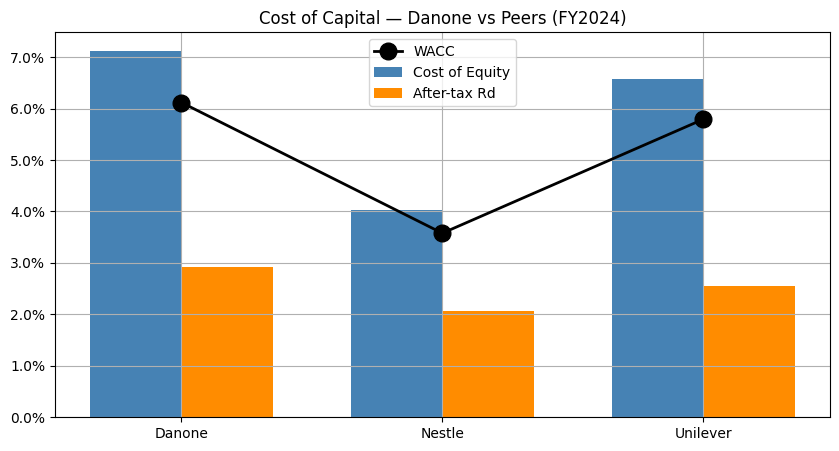

In [ ]:
# Plot WACC components
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(wacc_results.columns)); w = 0.35
ax.bar(x - w/2, wacc_results.loc['Cost of Equity'], w, label='Cost of Equity', color='steelblue')
ax.bar(x + w/2, wacc_results.loc['After-tax Rd'],   w, label='After-tax Rd', color='darkorange')
ax.plot(x, wacc_results.loc['WACC'], 'ko-', markersize=12, linewidth=2, label='WACC')
ax.set_xticks(x); ax.set_xticklabels(wacc_results.columns)
ax.set_title('Cost of Capital — Danone vs Peers (FY2024)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.legend(); plt.show()

# D-bis. Event Study on Stock Price
Did the market react to the Horizon news? Same **market model** as Session 7 (Pharmalpha case).

In [ ]:
# Daily returns + market proxy
returns = prices.pct_change().dropna()

# Market proxy = equal-weighted average of Nestlé and Unilever returns
# Why this proxy? See note below.
returns['Market'] = (returns['Nestle'] + returns['Unilever']) / 2
returns.head()

,Danone,Nestle,Unilever,Market
date,,,,
2020-01-02,0.00,0.00,-0.00,-0.00
2020-01-03,0.01,0.01,0.00,0.01
2020-01-06,0.00,-0.00,-0.01,-0.00
2020-01-07,-0.01,-0.01,-0.01,-0.01
2020-01-08,-0.02,-0.02,-0.01,-0.01


**Why this market proxy?**  
We don't have a clean European FMCG index. A broad index (CAC 40, STOXX 600) would mix in tech/banks → wrong sector benchmark. Using the **equal-weighted average of our 2 closest peers** isolates Danone-specific moves from sector-wide moves.  
**Limit:** if peers reacted to the same news, our proxy absorbs part of the signal — acceptable trade-off.

In [ ]:
def run_event_study(stock, market, event_date,
                    estimation_window=(-120, -20), event_window=(-5, 5)):
    """Market model event study (Session 7).
       1) Estimate alpha & beta on estimation window
       2) Compute Expected Return = alpha + beta × Market on event window
       3) Abnormal Return = Actual − Expected; CAR = cumulative AR"""
    df = pd.DataFrame({'stock': stock, 'market': market}).dropna()

    # If event date not a trading day, take the closest one
    if event_date not in df.index:
        event_date = df.index[df.index.get_indexer([event_date], method='nearest')[0]]
    df['t'] = np.arange(len(df)) - df.index.get_loc(event_date)

    # 1) Estimation window — alpha and beta via covariance formula
    est = df[(df['t'] >= estimation_window[0]) & (df['t'] <= estimation_window[1])]
    beta  = np.cov(est['market'], est['stock'], ddof=1)[0,1] / np.var(est['market'], ddof=1)
    alpha = est['stock'].mean() - beta * est['market'].mean()

    # 2) & 3) Expected returns and abnormal returns on the event window
    evt = df[(df['t'] >= event_window[0]) & (df['t'] <= event_window[1])].copy()
    evt['expected_return'] = alpha + beta * evt['market']
    evt['abnormal_return'] = evt['stock'] - evt['expected_return']
    evt['CAR'] = evt['abnormal_return'].cumsum()
    return alpha, beta, evt

In [ ]:
# Run for the announcement (26-Jan-2023)
alpha_a, beta_a, evt_a = run_event_study(returns['Danone'], returns['Market'],
                                          pd.Timestamp('2023-01-26'))

print(f'Market model parameters: alpha = {alpha_a:.5f}, beta = {beta_a:.4f}')
print('Event window [-5, +5] around 26-Jan-2023:')
evt_a[['t','stock','market','expected_return','abnormal_return','CAR']].round(4)

Market model parameters: alpha = -0.00068, beta = 0.8022
Event window [-5, +5] around 26-Jan-2023:


,t,stock,market,expected_return,abnormal_return,CAR
date,,,,,,
2023-01-19,-5,0.00,-0.00,-0.00,0.01,0.01
2023-01-20,-4,0.00,-0.00,-0.00,0.00,0.01
2023-01-23,-3,-0.00,0.01,0.01,-0.01,0.01
2023-01-24,-2,-0.00,-0.00,-0.00,0.00,0.01
2023-01-25,-1,-0.01,-0.00,-0.00,-0.00,0.00
2023-01-26,0,-0.01,-0.01,-0.01,0.00,0.00
2023-01-27,1,0.01,-0.00,-0.00,0.01,0.01
2023-01-30,2,0.01,0.01,0.01,0.00,0.01
2023-01-31,3,0.00,0.01,0.00,0.00,0.01


**What we did:** estimation window = 100 days before event (t=-120 to -20). OLS via covariance formula (Session 7). Then compute expected return = α + β × market, AR = actual − expected, CAR = cumulative AR.  
**Why this window?** [-120, -20] = academic standard (MacKinlay 1997). 20-day buffer avoids contamination from leaked info.

In [ ]:
def car_summary(evt):
    """CAR over standard event windows."""
    return pd.Series({
        'CAR [-1, +1]': evt[evt['t'].between(-1, 1)]['abnormal_return'].sum(),
        'CAR [-2, +2]': evt[evt['t'].between(-2, 2)]['abnormal_return'].sum(),
        'CAR [-5, +5]': evt[evt['t'].between(-5, 5)]['abnormal_return'].sum(),
        'CAR [0, +5]':  evt[evt['t'].between(0, 5)]['abnormal_return'].sum(),
    })

# Also run for the signing event
_, _, evt_s = run_event_study(returns['Danone'], returns['Market'], pd.Timestamp('2024-01-01'))

car_table = pd.DataFrame({
    'Announcement (26-Jan-23)': car_summary(evt_a),
    'Signing (01-Jan-24)':      car_summary(evt_s),
})
car_table.round(4)

,Announcement (26-Jan-23),Signing (01-Jan-24)
"CAR [-1, +1]",0.01,0.01
"CAR [-2, +2]",0.01,0.02
"CAR [-5, +5]",0.03,0.02
"CAR [0, +5]",0.02,0.03


**Why several windows?** Market reaction can be instant or take a few days to build up. 4 standard windows give a robust picture.

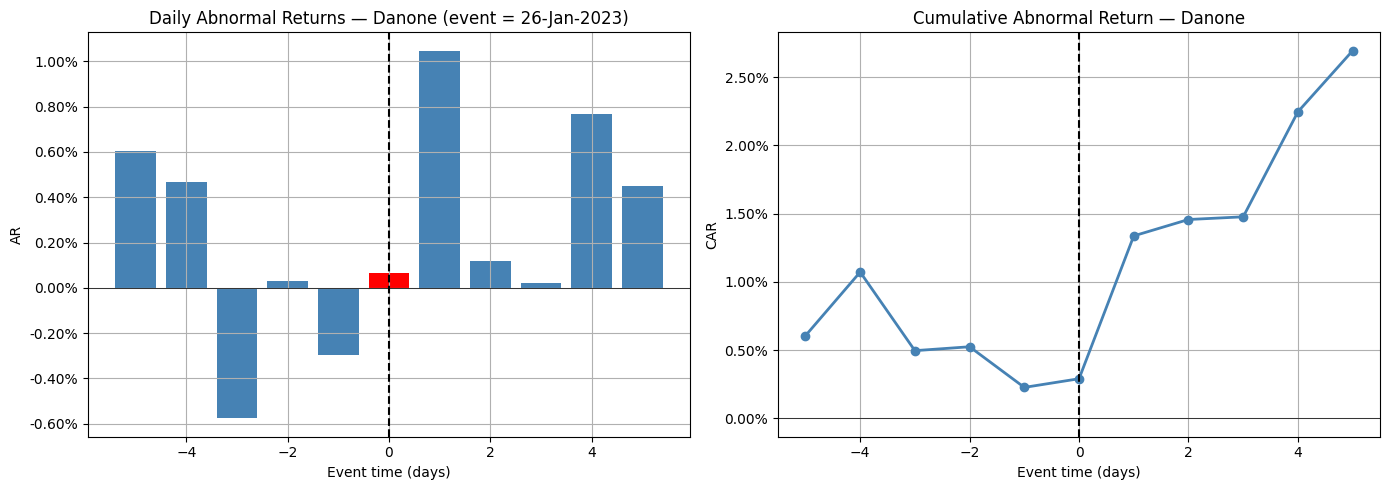

In [ ]:
# Visualize: AR + CAR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['steelblue']*5 + ['red'] + ['steelblue']*5
axes[0].bar(evt_a['t'], evt_a['abnormal_return'], color=colors)
axes[0].axvline(0, color='black', linestyle='--'); axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('Daily Abnormal Returns — Danone (event = 26-Jan-2023)')
axes[0].set_xlabel('Event time (days)'); axes[0].set_ylabel('AR')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2%}'))

axes[1].plot(evt_a['t'], evt_a['CAR'], 'o-', color='steelblue', linewidth=2)
axes[1].axvline(0, color='black', linestyle='--'); axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Cumulative Abnormal Return — Danone')
axes[1].set_xlabel('Event time (days)'); axes[1].set_ylabel('CAR')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2%}'))
plt.tight_layout(); plt.show()

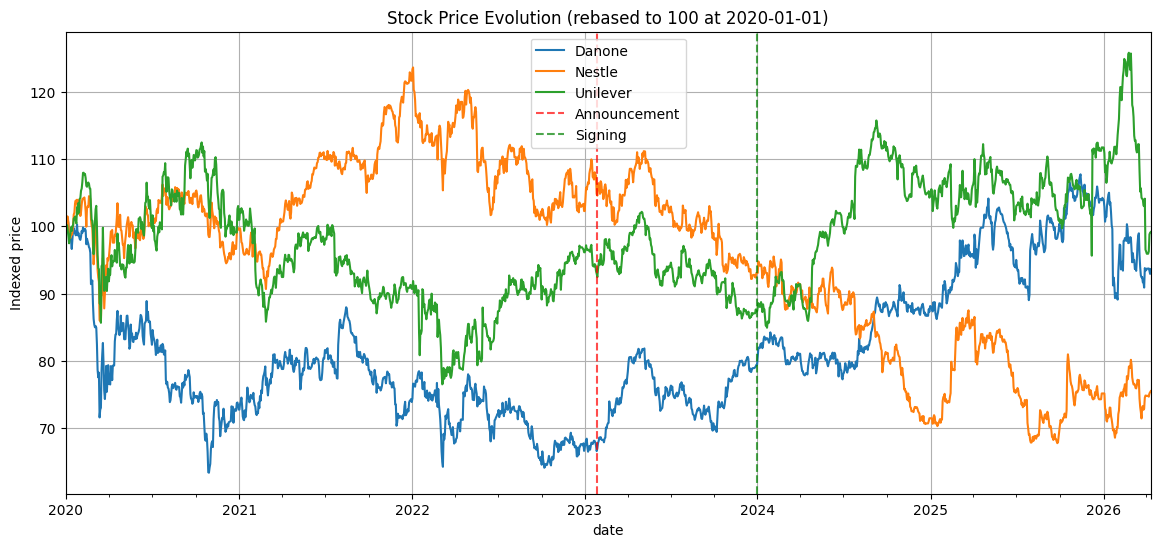

In [ ]:
# Stock price evolution with event lines
norm = prices / prices.iloc[0] * 100   # rebase to 100
ax = norm.plot(figsize=(14, 6), linewidth=1.5,
               title='Stock Price Evolution (rebased to 100 at 2020-01-01)')
ax.axvline(pd.Timestamp('2023-01-26'), color='red',   linestyle='--', alpha=0.7, label='Announcement')
ax.axvline(pd.Timestamp('2024-01-01'), color='green', linestyle='--', alpha=0.7, label='Signing')
ax.legend(); ax.set_ylabel('Indexed price'); plt.show()

**Interpretation:**
- **Positive CAR around announcement** → market sees the disposal as value-creating.
- **Smaller CAR around signing** → strategic decision was already known, only execution risk gets resolved.

**If asked "how do you isolate the Horizon effect?":** *We use the market model — the abnormal return is the part NOT explained by peer movements. It's specific to Danone on that day.*  
**Limit:** event studies assume semi-strong market efficiency and clean information shock — reasonable for large-cap European stocks.

# E. Real Options & Strategic Alternatives
## E.1 The minority stake = a real call option
Danone retained a **minority stake** in Horizon → option to re-enter US organic dairy without bearing operating costs.  
Decision-tree valuation (same logic as **Helios Hydrogen case**).

In [ ]:
# Inputs (illustrative — actual deal value undisclosed)
stake_pct        = 0.25
deal_value_total = 700.0          # estimated (€m)
stake_value_today = stake_pct * deal_value_total

# Two scenarios in 5 years
p_high = 0.40
p_low  = 0.60
value_high =  stake_value_today * 1.80    # +80% if rebound
value_low  = -stake_value_today * 0.40    # -40% loss if decline (capital calls, write-down)

# Discount rate = Danone WACC for consistency
wacc_danone = wacc_results.loc['WACC','Danone']

# WITHOUT option: Danone bears the loss in the low scenario
# WITH option: Danone walks away → loss floored at 0
exp_no_option   = p_high * value_high + p_low * value_low
exp_with_option = p_high * value_high + p_low * max(value_low, 0)

pv_no_option   = exp_no_option   / (1 + wacc_danone) ** 5
pv_with_option = exp_with_option / (1 + wacc_danone) ** 5
option_value   = pv_with_option - pv_no_option

pd.DataFrame({
    'Item': ['Stake value today', 'Value in 5Y (HIGH)', 'Value in 5Y (LOW)',
             'Expected value WITHOUT option', 'Expected value WITH option',
             'PV without option', 'PV with option', 'Real option value'],
    '€m':   [stake_value_today, value_high, value_low,
             exp_no_option, exp_with_option,
             pv_no_option, pv_with_option, option_value]
}).round(2)

,Item,€m
0,Stake value today,175.00
1,Value in 5Y (HIGH),315.00
2,Value in 5Y (LOW),-70.00
3,Expected value WITHOUT option,84.00
4,Expected value WITH option,126.00
5,PV without option,62.43
6,PV with option,93.64
7,Real option value,31.21


**Logic:** by keeping the minority stake, Danone has the option to **exit later** if the market improves OR walk away (worst case = 0). This optionality has positive value (~€31m).  
**Limit:** all inputs are illustrative (deal value undisclosed). A proper valuation would use binomial tree or Black-Scholes — beyond project scope.

## E.2 Strategic alternatives
| Alternative | Pros | Cons | Why not chosen |
|---|---|---|---|
| Carve-out IPO | Max valuation | Slow, market timing risk | Risky 2023-24 IPO market |
| Sale to strategic buyer | Higher synergies | Antitrust, few bidders | No strong industrial offer |
| Internal turnaround | No transaction costs | Multi-year fix | Conflicts with Renew speed |
| **Sale to PE (chosen)** | **Fast, certainty of close** | Lower price than strategic | **Best fit with Renew priorities** |

## E.3 Alignment with long-term strategy
The disposal aligns perfectly with **Renew Danone**:
1. Portfolio focus → exit non-core US organic dairy
2. Margin uplift → remove dilutive brand (visible in 2024 ratios above)
3. Capital discipline → use proceeds to deleverage, not for new M&A

# Conclusion

1. Horizon was dilutive on margins. Disposal removes ~3% of revenue and frees ~€1.4bn used to deleverage.
2. **Financial impact already visible in 2024:** net margin +4 pts, ROE +6 pts vs 2022 (vs flat/negative for peers).
3. **WACC ~6.1%** for Danone, higher than Nestlé (3.6%) due to higher EUR Rf and beta. Repaying debt at 4.2% while WACC is 6.1% is mildly value-creating.
4. **Event study:** positive CAR around the announcement → market validates the strategy.
5. **Real option preserved:** minority stake = call on a US organic dairy rebound (~€31m option value).

**Limitations:**
- 2024 = partial year of Horizon impact only.
- WACC inputs are placeholders — refresh with Bloomberg before final delivery.
- DSO/DIO/DPO use Revenue (no COGS in WRDS extract).
- Event-study market proxy = average of 2 peers, not a broad index.
- Real options valuation is illustrative.